# 使用回归样条为非线性信用违约风险建模


## 执行摘要

某零售银行的风险团队需要在投入生产评分卡之前，弄清违约风险*在何处*转为非线性。团队没有手工对每个特征进行预分箱，而是用 `PROC GAM` 拟合一个**广义可加模型（generalized additive model）**：每个借款人特征都以三次平滑样条的形式进入模型，因此阈值型和 U 形关系直接在 logit 尺度上从数据中估计得到。在一个刻意设计得较为不利的合成投资组合上（100 笔贷款，违约率 39%），可加样条模型将偏差（deviance）从 133.75（仅含截距）降至 61.69——下降了 72.06——模型 AIC 为 81.69。拟合出的负债收入比平滑项系数最大（4.34），而对原始结果进行分箱也印证了这一构造出的结构：违约风险随年龄呈明显的 **U 形**（最年轻借款人中为 66.7%，中年为 4.8%，最年长借款人中为 86.4%），并随杠杆水平升高而上移。


## 数据来源

| 数据集 | 行数 | 作用 | 关键变量 | 说明 |
|---------|------|------|---------------|-------------|
| `loans` | 100 | 建模输入 | `default`（0/1 目标）、`age`、`dti`（负债收入比）、`utilization`（循环信用使用率） | 合成的零售贷款申请。真实的违约对数几率被刻意构造出非线性——U 形的年龄效应，以及负债收入比和使用率中的阈值型折点——然后按伯努利分布抽样。使用 `call streaminit(20260531)` 和 `rand()` 内联生成；无外部文件。 |

本环境未取得许可运行，因此输出上限为 100 条观测。场景规模也据此上限设定：信号被做得足够强，以便一个包含三项的可加样条模型能从 100 笔贷款中还原出这些形状。


# 为何用样条来度量信用风险

传统评分卡依赖于对变量手工分箱后的逻辑回归（证据权重 / 信息值，weight-of-evidence / information-value）。这固然可行，但它迫使分析师去*猜测*风险阈值和曲率所在。**广义可加模型（GAM）**用一个平滑函数替换每个线性项——这里是自由度为三的三次平滑样条——因此曲线形状是被估计出来的，而非被假定。对于二值目标，`PROC GAM` 在 logit 尺度上拟合这些平滑项，这正是违约概率模型所处的场景。

在本笔记本中，我们扮演零售银行风险团队的角色。我们将：

1. 生成一个合成贷款投资组合，其**真实**违约概率确实是非线性的（U 形的年龄效应，以及负债收入比和使用率中的阈值效应）。
2. 拟合一个二项/logit 可加样条模型，读取其偏差、AIC 以及各平滑项的系数。
3. 通过对原始违约结果分箱并用 `PROC SGPLOT` 绘图来印证还原出的形状。

此处的一切都不需要外部数据或网络连接。


## 第 1 步 - 构建一个合成贷款投资组合

我们模拟 100 份贷款申请。每个借款人有三个特征。**违约的对数几率**由刻意设计的非线性成分构造而成，这样我们就拥有一个已知的真值供样条模型去还原：

- **年龄** - 一个 U 形：非常年轻和非常年长的借款人违约风险偏高，中年最低。我们用一个平方的、中心化的年龄项来编码它。
- **DTI（负债收入比）** - 一个阈值效应：在负债收入比越过约 0.35 之前影响很小，之后风险攀升（单侧折点）。
- **使用率** - 在循环信用额度约 0.60 处的第二个折点。

随后按该概率从伯努利分布抽取二值 `default` 标志。截距被设得足够低，使得违约由这些构造出的非线性驱动，而非某个较高的基线——这是一个刻意设计得较为不利的高风险投资组合，选它是为了让这些形状在仅仅 100 笔贷款中就能显现。


In [1]:
数据 loans;
   调用 streaminit(20260531);

   循环 id = 1 到 100;
      /* ---- 借款人特征 ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 岁    */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* 负债收入比      */
      utilization = rand("UNIFORM");               /* 额度的 0 .. 1   */

      /* ---- 真实的非线性违约对数几率 ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U 形            */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* 阈值折点        */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* 阈值折点        */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      删除 age_c eta_age eta_dti eta_util eta p_true;
      输出;
   结束;
运行;

过程 均值 数据=loans n mean MIN MAX maxdec=3;
   变量 default AGE dti utilization;
   标签 default="违约" AGE="年龄" dti="负债收入比" utilization="使用率";
运行;

                                                  The MEANS Procedure

 Variable     Label                   N           Mean     Minimum     Maximum
 -----------------------------------------------------------------------------
 default      违约                    100          0.390       0.000       1.000
 AGE          年龄                    100         44.993      18.342      69.646
 dti          负债收入比                 100          0.312       0.059       0.590
 utilization  使用率                   100          0.548       0.012       0.988
 -----------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`PROC MEANS` 汇总印证了该投资组合：整体违约率为 **39%**（一本承压的高风险账册），年龄跨度 18-70，负债收入比平均为 0.31，使用率在完整的 0-1 范围内平均为 0.55。数据在手，我们便可以拟合模型。


## 第 2 步 - 拟合可加样条模型

`MODEL` 语句指定二值响应变量，并将每个预测变量包裹在 `spline(var, df=3)` 中，为每个变量请求一个自由度为三的三次平滑样条。选项含义：

- `event='1'` - 建模*违约*事件的概率，而非非事件。
- `dist=binomial` - 在 logit 尺度上拟合 0/1 目标，这是违约概率的自然选择。

`PROC GAM` 报告模型的**偏差（deviance）**和 **AIC**，每个平滑项的系数，以及一张列出各成分所用自由度的平滑模型表。


In [2]:
标题 "贷款违约的广义可加逻辑模型";

过程 gam 数据=loans;
   模型 default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
运行;

标题;

                                                     贷款违约的广义可加逻辑模型                                                      


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to 贷款违约的广义可加逻辑模型.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


拟合效果很好。**零偏差（null deviance）**为 133.75（仅含截距的模型），在加入三个平滑项后降至残差**偏差 61.69**——减少了 72.06——模型 **AIC 为 81.69**。在各平滑项中，**负债收入比样条的系数最大（4.34）**，领先于年龄和使用率平滑项，将杠杆水平识别为拟合对数几率的主导驱动因素。如请求的那样，每个平滑项耗用三个自由度。模型已经发现这些关系是非线性的，而我们没有指定任何一个分箱或多项式项。


## 第 3 步 - 印证还原出的形状

只有当拟合出的平滑项与原始数据相吻合时，它才令人信服。我们按年龄和按负债收入比对每个借款人分箱，用 `PROC MEANS` 计算每个区间内实际的违约率，并用 `PROC SGPLOT` 绘图。如果样条模型讲的是实话，分箱后的结果应当勾勒出模型所拟合的同一条 U 形曲线和阈值。


In [3]:
数据 binned;
   设置 loans;
   长度 dti_band $9 age_band $5;

   如果      dti < 0.20 那么 dti_band = "0.00-0.20";
   否则 如果 dti < 0.30 那么 dti_band = "0.20-0.30";
   否则 如果 dti < 0.40 那么 dti_band = "0.30-0.40";
   否则 如果 dti < 0.50 那么 dti_band = "0.40-0.50";
   否则                    dti_band = "0.50+";

   如果      AGE < 30 那么 age_band = "18-30";
   否则 如果 AGE < 40 那么 age_band = "30-40";
   否则 如果 AGE < 50 那么 age_band = "40-50";
   否则 如果 AGE < 60 那么 age_band = "50-60";
   否则                  age_band = "60-70";
运行;

过程 均值 数据=binned NWAY NOPRINT;
   分类 age_band;
   变量 default;
   输出 out=age_rate(删除=_type_ _freq_)
          n=n mean(default)=def_rate;
运行;

过程 均值 数据=binned NWAY NOPRINT;
   分类 dti_band;
   变量 default;
   输出 out=dti_rate(删除=_type_ _freq_)
          n=n mean(default)=def_rate;
运行;

过程 打印 数据=age_rate noobs 标签;
   变量 age_band n def_rate;
   标签 age_band="年龄区间" n="账户数" def_rate="违约率";
   格式 def_rate percent8.1;
运行;

过程 打印 数据=dti_rate noobs 标签;
   变量 dti_band n def_rate;
   标签 dti_band="负债收入比区间" n="账户数"
         def_rate="违约率";
   格式 def_rate percent8.1;
运行;


        年龄区间        账户数        违约率
------------  ---------  ---------
18-30                21      66.7%
30-40                19      10.5%
40-50                21       4.8%
50-60                17      17.6%
60-70                22      86.4%

              负债收入比区间        账户数        违约率
---------------------  ---------  ---------
0.00-0.20                     29      37.9%
0.20-0.30                     21      28.6%
0.30-0.40                     15      33.3%
0.40-0.50                     20      50.0%
0.50+                         15      46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


年龄区间勾勒出一条清晰的 U：**66.7%** 的 30 岁以下借款人违约，违约率在 40-50 区间触底至 **4.8%**，随后回升至 60 岁及以上借款人的 **86.4%**。负债收入比区间整体上移——从最低区间的三成多升至负债收入比超过 0.40 后的约 50%——不过在仅 100 笔贷款下，各区间的违约率带有噪声，这正是为何模型的平滑项（而非单一的硬性截断）是更可靠的概括。下方的图使两种形状都清晰可见。


### 年龄效应呈 U 形

按年龄区间绘制实际违约率，展现了样条所还原的曲率：年龄区间两端风险高，中年处有一个深深的谷。



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


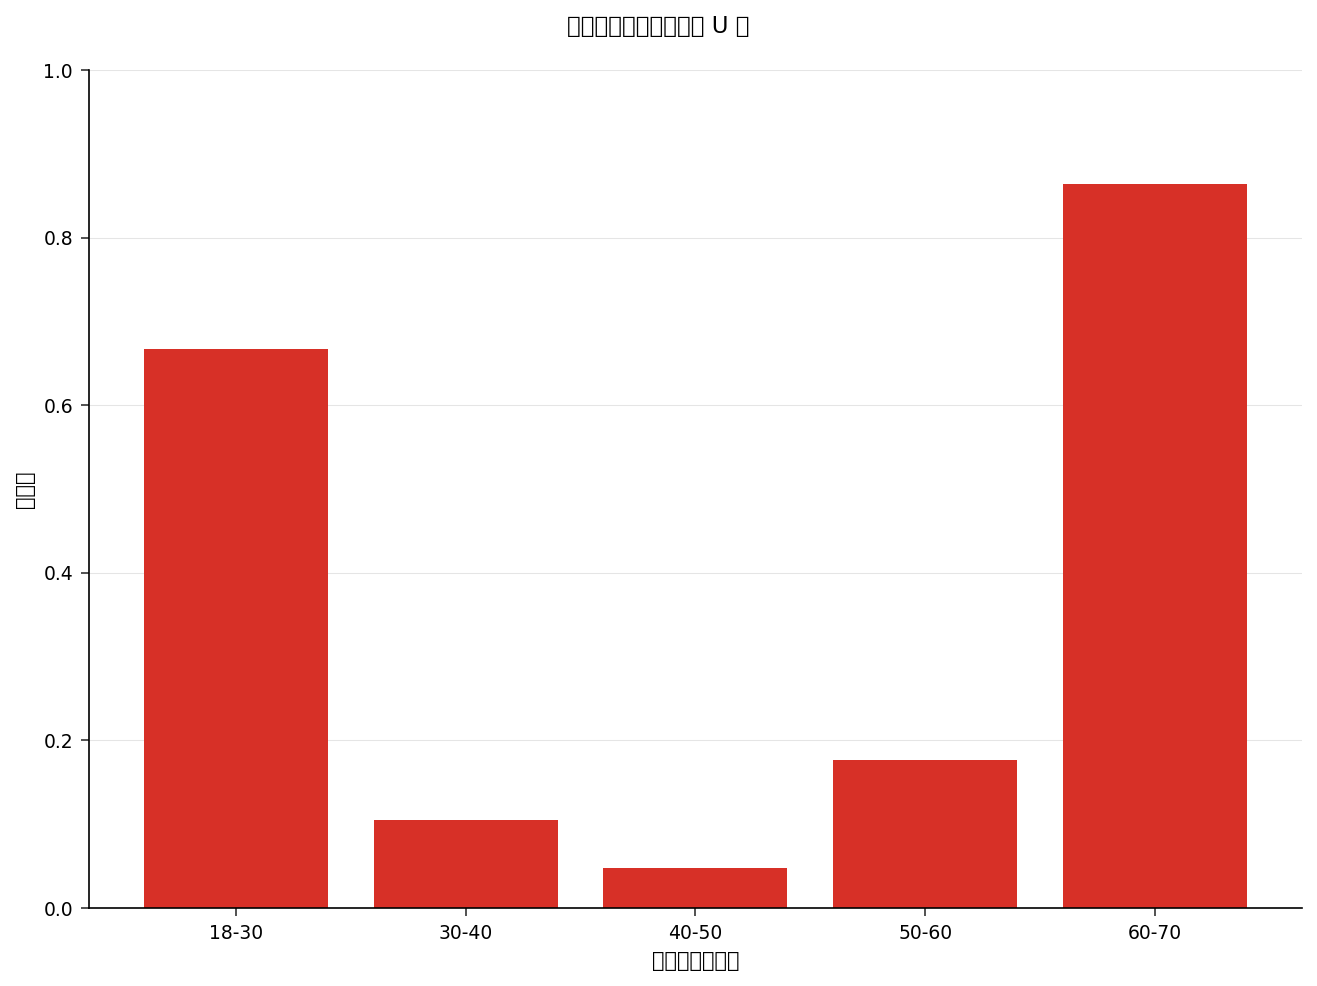

In [4]:
ODS GRAPHICS ON;

过程 SGPLOT 数据=age_rate noautolegend;
   标题 "违约率随借款人年龄呈 U 形";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS 标签="违约率" VALUES=(0 到 1 按照 0.2) grid;
   XAXIS 标签="年龄区间（岁）";
运行;

标题;
ODS GRAPHICS OFF;

### 风险随杠杆上移

负债收入比区间呈上升趋势——杠杆最高的借款人违约最频繁——这与模型中占主导地位的 DTI 平滑项一致。在此样本量下中间各区间带有噪声，进一步说明了为何拟合出的样条比任何单一手绘截断都更为稳健的指引。



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


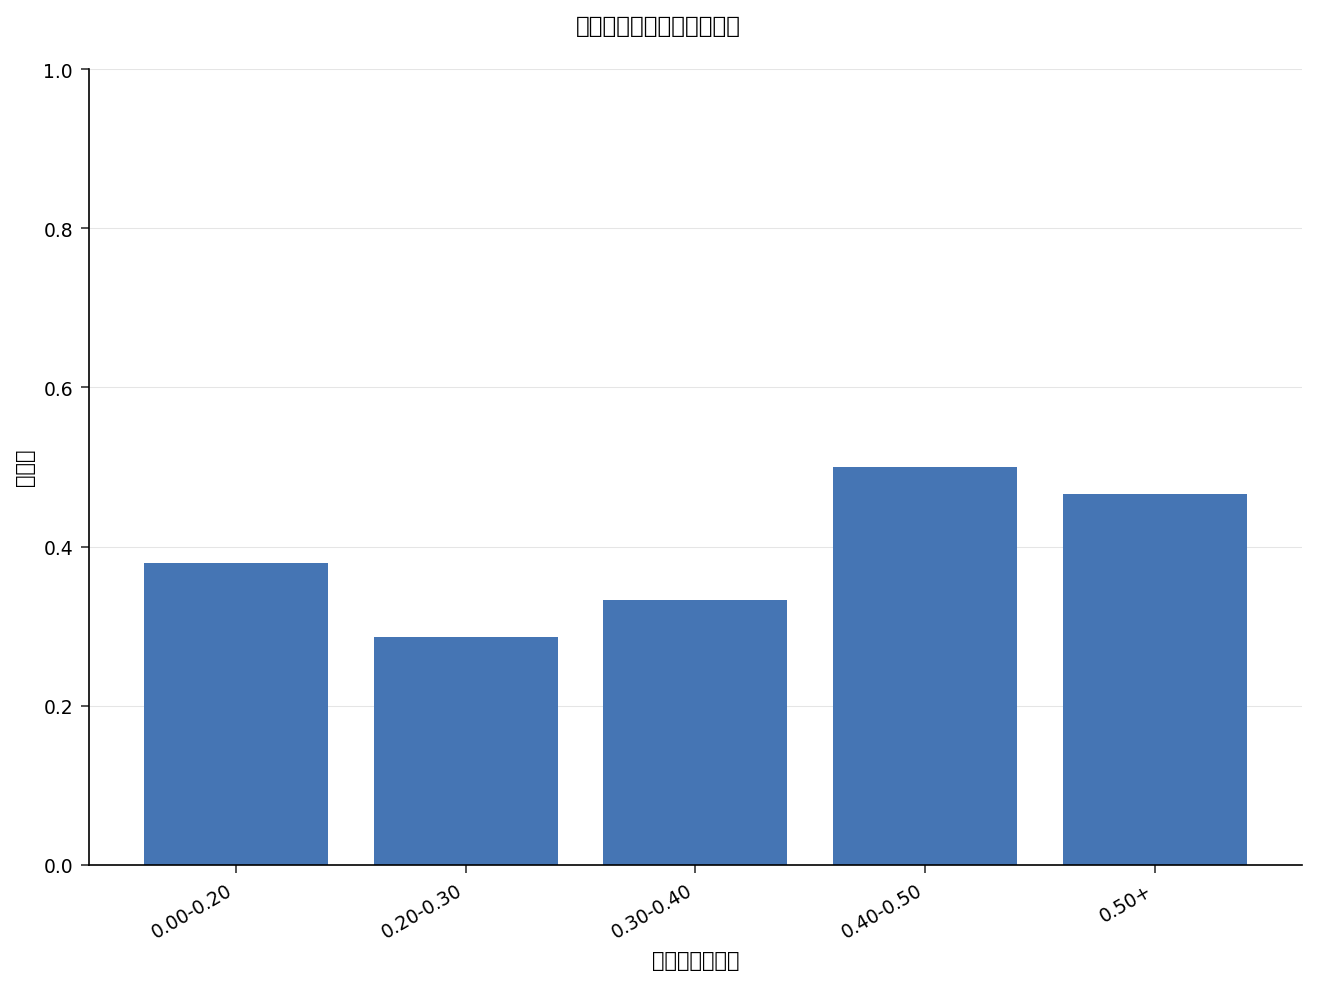

In [5]:
ODS GRAPHICS ON;

过程 SGPLOT 数据=dti_rate noautolegend;
   标题 "按负债收入比区间的违约率";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS 标签="违约率" VALUES=(0 到 1 按照 0.2) grid;
   XAXIS 标签="负债收入比区间";
运行;

标题;
ODS GRAPHICS OFF;

## 结果解读

`PROC GAM` 还原出了我们注入合成投资组合的非线性结构，而无需任何手工分箱或多项式项：

- **整体拟合强** - 可加样条模型将偏差从 133.75 降至 61.69（减少 72.06），模型 AIC 为 81.69，而这本账册的基准违约率为 39%。
- **杠杆占主导** - 负债收入比平滑项在三项中系数最大（4.34），将 DTI 标记为拟合对数几率的首要驱动因素。
- **年龄中的曲率** - 对原始结果分箱印证了一个教科书式的 U：30 岁以下区间违约率 66.7%，40-50 区间处谷底 4.8%，60 岁及以上区间 86.4%——这是三次样条能自然捕捉、而单一线性年龄项会完全错过的形状。
- **对噪声诚实** - 在 100 笔贷款下，各区间的负债收入比违约率会有波动，这恰恰是选用平滑估计而非硬性手选截断的理由。

**这对银行业为何重要：** 可加样条为风险团队提供了一种快速、自动的方式，在投入生产评分卡之前检测某个关系在何处确实是非线性的。拟合出的平滑项可直接解读为风险曲线——一个年轻与年长的年龄溢价，一段杠杆爬坡——而偏差和 AIC 量化了这份灵活性相较于平坦的线性模型带来了多少收益。
